# CHAPTER 15: _Post Processing Methods_

## The Preparations

### Installing the Libraries

In [1]:
%%capture
!pip install fairlearn

### Loading the Libraries

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, recall_score, ConfusionMatrixDisplay

# import solas_disparity as sd
from fairlearn.postprocessing import ThresholdOptimizer, plot_threshold_optimizer
import json

pd.set_option('display.max_columns', None)

import warnings
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
np.random.seed(271828)

## Generating the Synthetic Dataset

In [3]:
N_OBS = 100000

df = pd.DataFrame(
    data={
        'BMI': np.floor(np.random.randn(N_OBS) * 40),
        'Age': np.random.randint(low=20, high=81, size=N_OBS),
        'Smoker': np.random.binomial(n=1, p=0.20, size=N_OBS),
        'Female': np.random.binomial(n=1, p=0.4, size=N_OBS),
        'Male': np.nan,  # Placeholder so that the orders of the columns look nice
        'Logistic Error': np.random.logistic(loc=0, scale=1, size=N_OBS),
    }
)

df['Logistic Error'] = df['Logistic Error'] - df['Logistic Error'].mean()

df['Male'] = 1 - df['Female']

mask_male = df['Male'] == 1
rand_smoker = np.random.rand(N_OBS)
rand_bmi = np.random.randint(low=0, high=5, size=mask_male.sum())
rand_age = np.random.randint(low=0, high=15, size=mask_male.sum())

df.loc[mask_male & (rand_smoker >= 0.95), 'Smoker'] = 1
df.loc[mask_male, 'BMI'] = df.loc[mask_male, 'BMI'] + rand_bmi
df.loc[mask_male, 'Age'] = df.loc[mask_male, 'Age'] + rand_age

df['BMI'] = df['BMI'].clip(lower=10, upper=50)
df['Age'] = df['Age'].clip(lower=20, upper=80)

bmi_risk =  (0.003472 * (df['BMI']**2)) - (0.1528 * df['BMI']) + 1.7806
age_risk = 0.0000863 * (df['Age'] ** 2.085)

smoker_risk = 0.25 * df['Smoker']
male_risk = 0.2 * mask_male

df['Measurable Risk'] = -8 + 2.5 * (bmi_risk + age_risk + smoker_risk + male_risk)
df['True Risk'] = df['Measurable Risk'] + df['Logistic Error']
df['Heart Attack'] = (df['True Risk'] > 0.0).astype(int)

In [4]:
df.groupby(by=['Female'])[['Age', 'BMI', 'Smoker', 'Heart Attack']].mean()

,Age,BMI,Smoker,Heart Attack
Female,,,,
0,56.272756,19.889960,0.242437,0.099269
1,50.047615,19.153012,0.202686,0.063830


In [5]:
df.groupby(by=['Female'])[['Age', 'BMI', 'Smoker', 'Heart Attack']].mean().map('{:.2f}'.format)

,Age,BMI,Smoker,Heart Attack
Female,,,,
0,56.27,19.89,0.24,0.10
1,50.05,19.15,0.20,0.06


In [6]:
df.groupby(by=['Female'])[['Age', 'BMI', 'Smoker', 'Heart Attack']].mean().map('{:.2f}'.format)

,Age,BMI,Smoker,Heart Attack
Female,,,,
0,56.27,19.89,0.24,0.10
1,50.05,19.15,0.20,0.06


In [7]:
df['Heart Attack'].value_counts(normalize=True).map('{:.2%}'.format)

,proportion
Heart Attack,
0,91.48%
1,8.52%


## Building the Predicitve Model

### Splitting dataset

In [8]:
train, valid = train_test_split(df, test_size=0.3, random_state=618)
print(train.shape, valid.shape)
train.sample(n=3, random_state=618)

(70000, 9) (30000, 9)


,BMI,Age,Smoker,Female,Male,Logistic Error,Measurable Risk,True Risk,Heart Attack
96325,27.0,80,0,0,1,-0.931735,-5.030800,-5.962535,0
71179,10.0,66,1,0,1,0.027162,-4.033663,-4.006501,0
27734,10.0,62,0,1,0,1.665600,-5.322657,-3.657056,0


### Fitting the model

In [9]:
features = ['BMI', 'Age', 'Smoker', 'Female']
label = 'Heart Attack'

base_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=2,
    learning_rate=0.05,
    random_state=618,
    eval_metric='logloss'
).fit(
    X=train[features],
    y=train[label],
)

### Feature importance

In [10]:
pd.Series(
    data=base_model.feature_importances_,
    index=base_model.get_booster().feature_names,
).sort_values(ascending=False).rename('Feature').map('{:.2f}'.format)

,Feature
BMI,0.85
Female,0.07
Smoker,0.06
Age,0.03


### Accuracy metrics

In [11]:
train_pred_proba = pd.Series(data=base_model.predict_proba(train[features])[:, 1], index=train.index)
train_auc = metrics.roc_auc_score(
    y_true=train[label],
    y_score=train_pred_proba,
)

valid_pred_proba = pd.Series(data=base_model.predict_proba(valid[features])[:, 1], index=valid.index)
valid_auc = metrics.roc_auc_score(
    y_true=valid[label],
    y_score=valid_pred_proba,
)
print(f'Training Set ROC-AUC:   {train_auc:.4f}')
print(f'Validation Set ROC-AUC: {valid_auc:.4f}')

Training Set ROC-AUC:   0.9612
Validation Set ROC-AUC: 0.9529


## Evaluating the model’s fairness

In [12]:
female_mean = valid_pred_proba[valid['Female'] == 1].mean()
male_mean = valid_pred_proba[valid['Female'] == 0].mean()

print(f"Mean valid_pred_proba for Female: {female_mean:.4f}")
print(f"Mean valid_pred_proba for Male: {male_mean:.4f}")

Mean valid_pred_proba for Female: 0.0664
Mean valid_pred_proba for Male: 0.0981


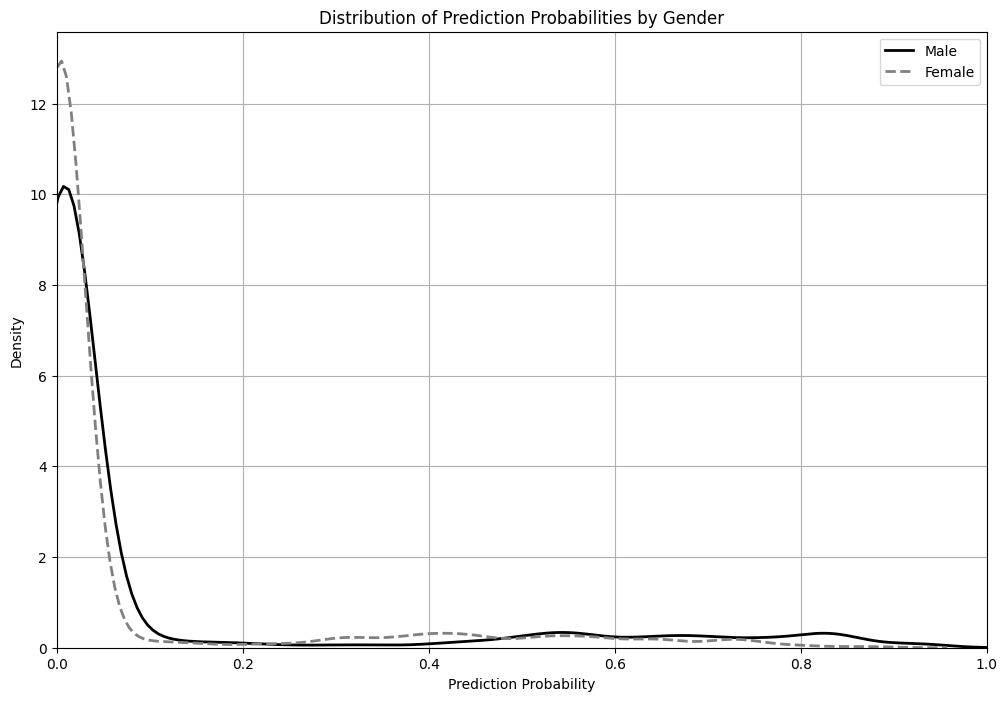

In [13]:
plt.figure(figsize=(12, 8))
sns.kdeplot(valid_pred_proba[valid['Female'] == 0], label='Male', color='black', linestyle='-', linewidth=2)
sns.kdeplot(valid_pred_proba[valid['Female'] == 1], label='Female', color='gray', linestyle='--', linewidth=2)
plt.title('Distribution of Prediction Probabilities by Gender')
plt.xlabel('Prediction Probability')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.xlim(0, 1)
plt.show()

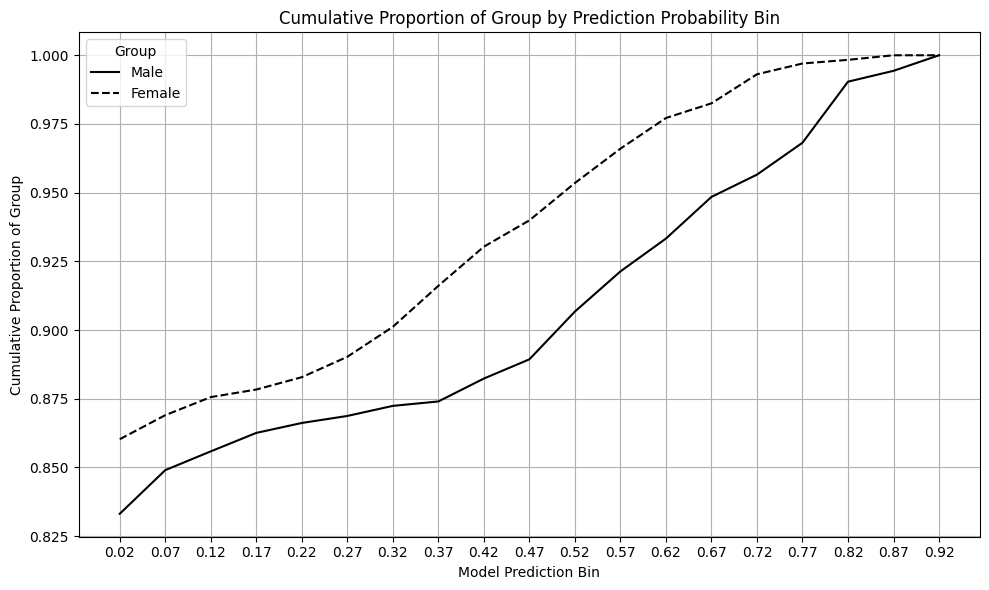

In [14]:
pred_bin = pd.cut(
    x=valid_pred_proba,
    bins=[x / 100 for x in range(0, 101, 5)],
    labels=[f'{x / 100:.2f}' for x in range(2, 101, 5)],
)

pct = valid.groupby(by=pred_bin, observed=True)[['Male', 'Female']].sum() / valid[['Male', 'Female']].sum()
cum_pct = pct.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(cum_pct.index, cum_pct['Male'], color='black', linestyle='-', label='Male')
plt.plot(cum_pct.index, cum_pct['Female'], color='black', linestyle='--', label='Female')

plt.xlabel('Model Prediction Bin')
plt.ylabel('Cumulative Proportion of Group')
plt.title('Cumulative Proportion of Group by Prediction Probability Bin')
plt.legend(title='Group')
plt.grid(True)
plt.tight_layout()
plt.show()

## Calculate Group Score Cutoffs

In [15]:
group_score_cutoffs = (
    train_pred_proba
    .quantile(q=[x / 1000 for x in range(1, 1000, 1)])
    .sort_index(ascending=False)
    .to_frame(name='Cutoff_Score')
).drop_duplicates(keep='last')

# Change the order of the quantiles, so the highest score is 1% and the lowest score is 99%:
group_score_cutoffs.index = pd.Index(
    data=np.round(1 - group_score_cutoffs.index, 8),
    name='Percentile',
)

In [16]:
group_score_cutoffs

,Cutoff_Score
Percentile,
0.002,0.927477
0.003,0.925859
0.004,0.885642
0.005,0.875562
0.006,0.858628
...,...
0.995,0.000576
0.996,0.000517
0.997,0.000470


# Evaluating base model disparity at 5% outreach

In [17]:
def evaluate_model_at_percentile(percentile, current_mask):
    cutoff_score = group_score_cutoffs.loc[percentile, 'Cutoff_Score']
    print(f"Percentile: {percentile:.4f}")
    print(f"Cutoff Score: {cutoff_score:.4f}")

    valid_filtered = valid[current_mask]
    valid_pred_proba_filtered = valid_pred_proba[current_mask]

    valid_pred_binary = (valid_pred_proba_filtered >= cutoff_score).astype(int)
    cm = confusion_matrix(valid_filtered[label], valid_pred_binary)

    tn, fp, fn, tp = cm.ravel()
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")

    op = (tp+fp)/(tp+fp+tn+fn)
    print(f"Outreach Percent: {op:.4f}")

    tpr = recall_score(valid_filtered[label], valid_pred_binary)
    print(f"True Positive Rate (TPR): {tpr:.4f}")
    return op, tpr

In [18]:
percentile = 0.05

female_mask = valid['Female'] == 1
print("--- Evaluating for Female Group ---")
op_female, tpr_base_female = evaluate_model_at_percentile(percentile, female_mask)

male_mask = valid['Female'] == 0
print("\n--- Evaluating for Male Group ---")
op_male, tpr_base_male = evaluate_model_at_percentile(percentile, male_mask)

all_mask = pd.Series(True, index=valid.index)
print("\n--- Evaluating for All Groups ---")
op_all, tpr_base_all = evaluate_model_at_percentile(percentile, all_mask)

print("\n")
air_ratio = op_female / op_male
print(f"AIR for Female to Male Outreach: {air_ratio:.4f}")

tpr_air_ratio = tpr_base_female / tpr_base_male
print(f"AIR for Female to Male TPR: {tpr_air_ratio:.4f}")

--- Evaluating for Female Group ---
Percentile: 0.0500
Cutoff Score: 0.6471
TN: 11121
FP: 95
FN: 572
TP: 212
Outreach Percent: 0.0256
True Positive Rate (TPR): 0.2704

--- Evaluating for Male Group ---
Percentile: 0.0500
Cutoff Score: 0.6471
TN: 15922
FP: 282
FN: 851
TP: 945
Outreach Percent: 0.0682
True Positive Rate (TPR): 0.5262

--- Evaluating for All Groups ---
Percentile: 0.0500
Cutoff Score: 0.6471
TN: 27043
FP: 377
FN: 1423
TP: 1157
Outreach Percent: 0.0511
True Positive Rate (TPR): 0.4484


AIR for Female to Male Outreach: 0.3753
AIR for Female to Male TPR: 0.5139


# FairLearn Threshold Optimizer

In [19]:
threshold_optimizer = ThresholdOptimizer(
    estimator=base_model,
    constraints='selection_rate_parity',
    objective="true_positive_rate",
    predict_method="predict_proba",
    prefit=True,
).fit(X=train[features], y=train[label], sensitive_features=train['Female'])

In [20]:
threshold_rules_by_group = threshold_optimizer.interpolated_thresholder_.interpolation_dict
print(json.dumps(threshold_rules_by_group, default=str, indent=4))

{
    "0": {
        "p0": 0.9724404761904776,
        "operation0": "[>0.0016087712137959898]",
        "p1": 0.027559523809522424,
        "operation1": "[>-inf]"
    },
    "1": {
        "p0": 0.529797421731124,
        "operation0": "[>0.0010049112606793642]",
        "p1": 0.470202578268876,
        "operation1": "[>-inf]"
    }
}


In [21]:
postprocessed_predictions = threshold_optimizer.predict(
    X=valid[features],
    sensitive_features=valid['Female'],
    random_state=12345
)

/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1. 1. 1. ... 1. 1. 1.]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[


In [22]:
male_mask = valid['Female'] == 0
female_mask = valid['Female'] == 1

groups = {
    "Male": (postprocessed_predictions[male_mask], valid[label][male_mask]),
    "Female": (postprocessed_predictions[female_mask], valid[label][female_mask]),
    "All": (postprocessed_predictions, valid[label])
}

for name, (preds, true) in groups.items():
    pos_pct = 100 * preds.mean()
    neg_pct = 100 - pos_pct

    tp = ((preds == 1) & (true == 1)).sum()
    actual_pos = (true == 1).sum()
    tpr = 100 * tp / actual_pos

    outreach = preds.mean()

    print(
        f"{name} Patients - Positive: {pos_pct:.2f}%, "
        f"Negative: {neg_pct:.2f}%, "
        f"TPR: {tpr:.2f}%, "
        f"Outreach Percent: {outreach:.4f}"
    )

Male Patients - Positive: 97.06%, Negative: 2.94%, TPR: 100.00%, Outreach Percent: 0.9706
Female Patients - Positive: 96.91%, Negative: 3.09%, TPR: 99.62%, Outreach Percent: 0.9691
All Patients - Positive: 97.00%, Negative: 3.00%, TPR: 99.88%, Outreach Percent: 0.9700


# Searching for Post-Processing Thresholds

In [23]:
cutoff_results = pd.DataFrame()

for group_j in ['All', 'Female', 'Male']:

    group_mask = pd.Series(1, index=train.index) if group_j == 'All' else train[group_j] == 1

    for cut_i in group_score_cutoffs.itertuples():

        train_outreach_ij = train_pred_proba.loc[group_mask == 1] > cut_i.Cutoff_Score
        train_label_ij = train.loc[group_mask == 1, label]

        cm_ij = metrics.confusion_matrix(
            y_true=train_label_ij,
            y_pred=train_outreach_ij,
        ).ravel()
        cm_ij
        cutoff_results_i = pd.Series(
            data=cm_ij,
            index=['TN', 'FP', 'FN', 'TP'],
        )
        cutoff_results_i = cutoff_results_i.to_frame(name=(cut_i.Index, cut_i.Cutoff_Score, group_j)).T
        cutoff_results_i.index.names = ['Percentile', 'Score Cut', 'Group']
        cutoff_results = pd.concat([cutoff_results, cutoff_results_i], axis=0)

cutoff_results = cutoff_results.sort_index(level=['Percentile', 'Score Cut', 'Group'])

In [24]:
cutoff_results

TN     FP    FN    TP
Percentile Score Cut Group                           
0.002      0.927477  All     64063      2  5895    40
                     Female  26081      0  1759     0
                     Male    37982      2  4136    40
0.003      0.925859  All     64058      7  5737   198
                     Female  26081      0  1759     0
...                            ...    ...   ...   ...
0.998      0.000435  Female    131  25950     0  1759
                     Male        9  37975     0  4176
0.999      0.000341  All        71  63994     0  5935
                     Female     65  26016     0  1759
                     Male        6  37978     0  4176

[1725 rows x 4 columns]

#### [2]

In [25]:
def get_metrics(res: pd.DataFrame) -> pd.DataFrame:

    res['Outreach Percent'] = (res['TP'] + res['FP']) / (res['TP'] + res['FP'] + res['TN'] + res['FN'])
    res['TPR'] = res['TP'] / (res['TP'] + res['FN'])
    res['PPV'] = res['TP'] / (res['TP'] + res['FP'])
    res['Accuracy'] = (res['TP'] + res['TN']) / (res['TP'] + res['FP'] + res['TN'] + res['FN'])

    res.loc[pd.IndexSlice[:, :, 'Female'], 'Outreach Percent Ratio'] = res.loc[pd.IndexSlice[:, :, 'Female'], 'Outreach Percent'].values / res.loc[pd.IndexSlice[:, :, 'Male'], 'Outreach Percent'].values
    res.loc[pd.IndexSlice[:, :, 'Female'], 'TPR Ratio'] = res.loc[pd.IndexSlice[:, :, 'Female'], 'TPR'].values / res.loc[pd.IndexSlice[:, :, 'Male'], 'TPR'].values
    res.loc[pd.IndexSlice[:, :, 'Female'], 'PPV Ratio'] = res.loc[pd.IndexSlice[:, :, 'Female'], 'PPV'].values / res.loc[pd.IndexSlice[:, :, 'Male'], 'PPV'].values
    res.loc[pd.IndexSlice[:, :, 'Female'], 'Accuracy Ratio'] = res.loc[pd.IndexSlice[:, :, 'Female'], 'Accuracy'].values / res.loc[pd.IndexSlice[:, :, 'Male'], 'Accuracy'].values
    return res

cutoff_results = get_metrics(cutoff_results)

In [26]:
cutoff_results.shape

(1725, 12)

In [27]:
cutoff_results.loc[pd.IndexSlice[0.10:0.102, :, :]].style.format(
    {x: '{:.2%}' for x in cutoff_results.columns if x not in ['TN', 'FP', 'FN', 'TP']} |
    {x: '{:,.0f}' for x in cutoff_results.columns if x in ['TN', 'FP', 'FN', 'TP']},
    na_rep='',
)

In [28]:
cutoff_results.loc[pd.IndexSlice[0.20:0.203, :, :]].style.format(
    {x: '{:.2%}' for x in cutoff_results.columns if x not in ['TN', 'FP', 'FN', 'TP']} |
    {x: '{:,.0f}' for x in cutoff_results.columns if x in ['TN', 'FP', 'FN', 'TP']},
    na_rep='',
)

In [29]:
metrics_considered = ['TPR', 'PPV', 'Accuracy', 'Outreach Percent']

metric_to_equalize = 'Outreach Percent'
value_of_metric_when_equalized = 0.15

female_results = cutoff_results.loc[pd.IndexSlice[:, :, 'Female'], :]
female_equalized_metric_index = (np.abs(female_results[metric_to_equalize] - value_of_metric_when_equalized)).idxmin()
female_equalized_metric = female_results.loc[[female_equalized_metric_index], ['TN', 'FP', 'FN', 'TP']].copy()

male_results = cutoff_results.loc[pd.IndexSlice[:, :, 'Male'], :]
male_equalized_metric_index = (np.abs(male_results[metric_to_equalize] - value_of_metric_when_equalized)).idxmin()
male_equalized_metric = male_results.loc[[male_equalized_metric_index], ['TN', 'FP', 'FN', 'TP']].copy()

equalized_metric = pd.concat(
    objs=(
        female_equalized_metric,
        male_equalized_metric,
    ),
    axis=0,
)
equalized_metric.reset_index()[['Score Cut', 'Group']]

,Score Cut,Group
0,0.022904,Female
1,0.105582,Male


In [30]:
sum_grps = equalized_metric.sum(axis=0).to_frame(name=(np.nan, np.nan, 'Adjusted All')).T
sum_grps.index.names = ['Percentile', 'Score Cut', 'Group']

equalized_metric = pd.concat(
    objs=(
        equalized_metric,
        sum_grps,
    ),
    axis=0,
)

equalized_metric = get_metrics(equalized_metric)
equalized_metric = (
    equalized_metric
    .drop(columns=['TP', 'FP', 'FN', 'TN'])
    .reset_index(level=['Percentile'], drop=True)
    .reset_index(drop=False)
)

equalized_overall_cutoff = equalized_metric.loc[equalized_metric['Group'].eq('Adjusted All'), 'Outreach Percent'].values[0]
closest_cut = pd.Series(np.abs(cutoff_results.index.get_level_values('Percentile') - equalized_overall_cutoff), index=cutoff_results.index)
overall_outreach_percent = closest_cut.idxmin()[0]

In [31]:
print(f'Baseline - Overall Outreach Percent: {overall_outreach_percent:.2%}')
baseline_comparison = cutoff_results.loc[pd.IndexSlice[overall_outreach_percent, :, ['Female', 'Male', 'All']], :]
display(baseline_comparison.drop(columns=['TP', 'FP', 'FN', 'TN']).reset_index().style.format(na_rep='', precision=3).hide(axis=0))

Baseline - Overall Outreach Percent: 15.00%


Percentile,Score Cut,Group,Outreach Percent,TPR,PPV,Accuracy,Outreach Percent Ratio,TPR Ratio,PPV Ratio,Accuracy Ratio
0.150,0.062,Female,0.133,0.940,0.447,0.923,0.825,1.020,0.789,1.000
0.150,0.062,Male,0.161,0.921,0.566,0.922,,,,
0.150,0.062,All,0.150,0.927,0.524,0.922,,,,


In [32]:
print(f'Equalized - Overall Outreach Percent: {overall_outreach_percent:.2%}')
display(equalized_metric.style.format(na_rep='', precision=3).hide(axis=0))

Equalized - Overall Outreach Percent: 15.00%


Score Cut,Group,Outreach Percent,TPR,PPV,Accuracy,Outreach Percent Ratio,TPR Ratio,PPV Ratio,Accuracy Ratio
0.023,Female,0.150,0.952,0.402,0.907,0.995,1.044,0.669,0.974
0.106,Male,0.150,0.912,0.601,0.931,,,,
,Adjusted All,0.150,0.924,0.522,0.922,,,,


#### [6]